# SVD and DMD on COBE Sea Surface Temperature

This notebook loads the COBE monthly sea surface temperature dataset, vectorizes the ocean points, computes a proper orthogonal decomposition (SVD), and then builds a reduced-order dynamic mode decomposition (DMD) model.

In [1]:
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from netCDF4 import Dataset

In [2]:
filename = 'sst.mon.mean.nc'
url = 'https://downloads.psl.noaa.gov/Datasets/COBE/sst.mon.mean.nc'

if not os.path.isfile(filename):
    print(f'Downloading {filename}...')
    urllib.request.urlretrieve(url, filename)

with Dataset(filename, 'r') as nc:
    sst = nc.variables['sst'][:]
    lon = nc.variables['lon'][:]
    lat = nc.variables['lat'][:]
    time = nc.variables['time'][:]

# The original Julia notebook uses dimensions (lon, lat, time).
# Depending on the file layout, transpose if necessary.
if sst.shape[0] == lon.size and sst.shape[1] == lat.size:
    sst_data = np.array(sst, dtype=np.float64)
elif sst.shape[-1] == lon.size and sst.shape[-2] == lat.size:
    sst_data = np.transpose(sst, (2, 1, 0)).astype(np.float64)
else:
    raise ValueError('Unexpected SST shape: ' + str(sst.shape))

# Convert masked values to NaN if needed.
if np.ma.is_masked(sst_data):
    sst_data = sst_data.filled(np.nan)

# Create year/month arrays for the time axis.
nmonths = time.shape[0]
year = 1891 + np.floor_divide(np.arange(nmonths), 12)
month = np.mod(np.arange(nmonths), 12) + 1

print('sst_data shape =', sst_data.shape)
print('lon shape =', lon.shape, 'lat shape =', lat.shape, 'time steps =', nmonths)

sst_data shape = (360, 180, 1590)
lon shape = (360,) lat shape = (180,) time steps = 1590


In [4]:
def create_vectors(sst, lon, lat):
    valid_mask = np.isfinite(sst[..., 0])
    lon_valid = lon[valid_mask.any(axis=1)] if sst.ndim == 3 else lon[valid_mask]  # fallback
    # Flatten the grid and keep only ocean points from the first time slice.
    idx_lon, idx_lat = np.where(valid_mask)
    Xlon = lon[idx_lon]
    Xlat = lat[idx_lat]
    SST = sst[valid_mask, :]
    return Xlon, Xlat, SST

def normalize_vector(x):
    x = np.asarray(x, dtype=np.float64)
    finite = np.isfinite(x)
    if not np.any(finite):
        return x
    xmin = np.nanmin(x)
    xmax = np.nanmax(x)
    if xmax == xmin:
        return np.zeros_like(x)
    return (x - xmin) / (xmax - xmin)

In [5]:
nstudy = 120
i_start = nmonths - nstudy
i_end = nmonths

Xlon, Xlat, SST = create_vectors(sst_data[:, :, i_start:i_end], lon, lat)
year_study = year[i_start:i_end]
month_study = month[i_start:i_end]

print('Xlon shape =', Xlon.shape)
print('SST shape =', SST.shape)

Xlon shape = (43799,)
SST shape = (43799, 120)


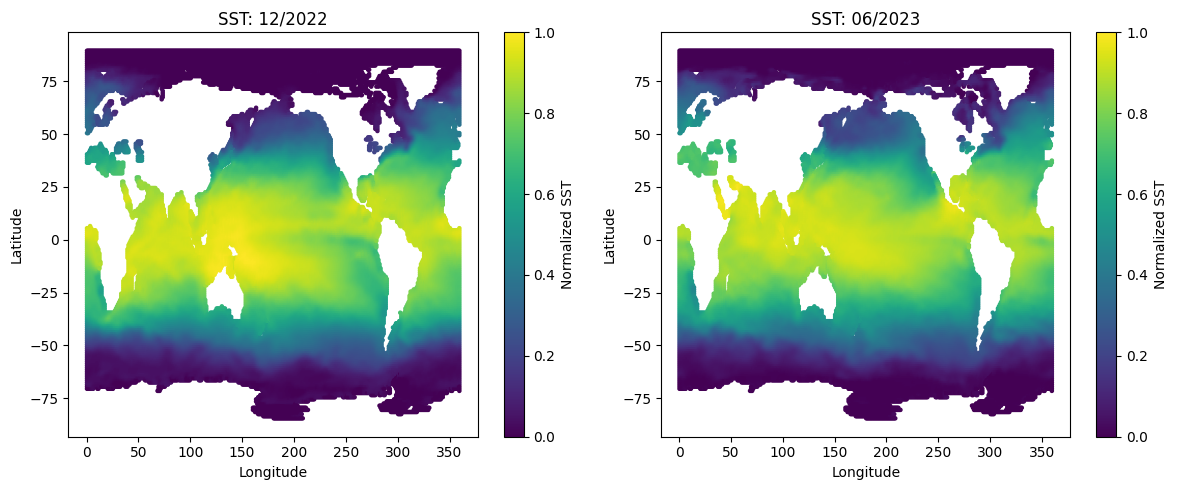

In [6]:
plt.figure(figsize=(12, 5))
for k, idx in enumerate([nstudy - 7, nstudy - 1], start=1):
    plt.subplot(1, 2, k)
    sc = plt.scatter(Xlon, Xlat, c=normalize_vector(SST[:, idx]), s=5, cmap='viridis')
    plt.colorbar(sc, label='Normalized SST')
    plt.title(f'SST: {int(month_study[idx]):02d}/{int(year_study[idx])}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
plt.tight_layout()

In [7]:
Z = SST[:, :-1]
Z_dash = SST[:, 1:]
U, S, Vt = svd(Z, full_matrices=False)

print('U shape =', U.shape)
print('S shape =', S.shape)
print('Vt shape =', Vt.shape)

U shape = (43799, 119)
S shape = (119,)
Vt shape = (119, 119)


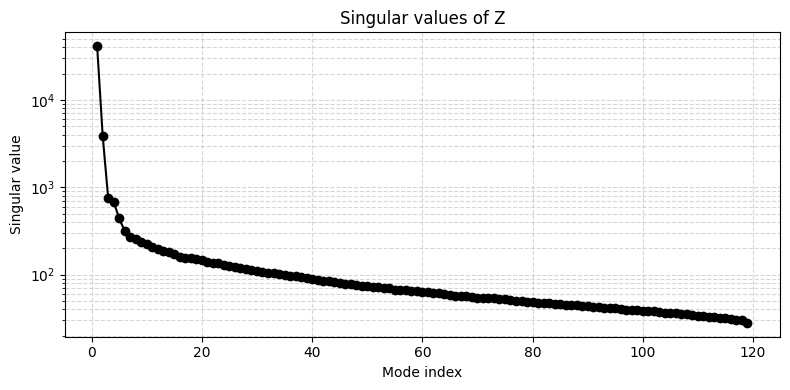

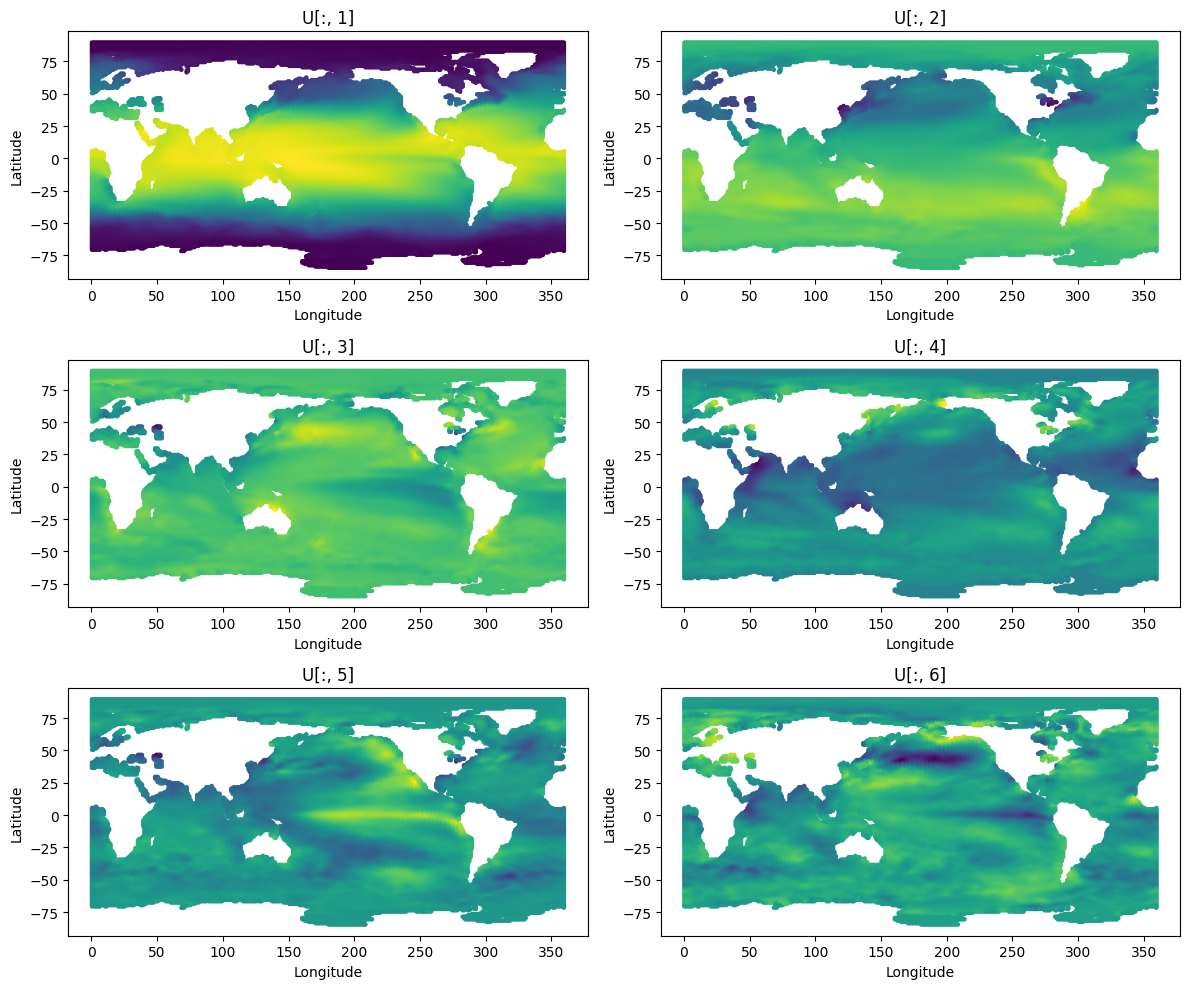

In [8]:
plt.figure(figsize=(8, 4))
plt.semilogy(np.arange(1, S.size + 1), S, 'o-', color='black')
plt.xlabel('Mode index')
plt.ylabel('Singular value')
plt.title('Singular values of Z')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()

n_modes = 6
plt.figure(figsize=(12, 10))
for k in range(n_modes):
    plt.subplot(3, 2, k + 1)
    plt.scatter(Xlon, Xlat, c=normalize_vector(U[:, k]), s=5, cmap='viridis')
    plt.title(f'U[:, {k + 1}]')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
plt.tight_layout()

In [9]:
r = 100
Ur = U[:, :r]
Sr = S[:r]
Vr = Vt[:r, :].T
A_tilde = Ur.T @ Z_dash @ Vr @ np.diag(1.0 / Sr)
mu, P = np.linalg.eig(A_tilde)
lambda_cont = np.log(mu) * 12.0
omega = np.imag(lambda_cont)
order = np.argsort(np.abs(omega))
mu = mu[order]
lambda_cont = lambda_cont[order]
omega = omega[order]
P = P[:, order]
Phi = Z_dash @ Vr @ np.diag(1.0 / Sr) @ P

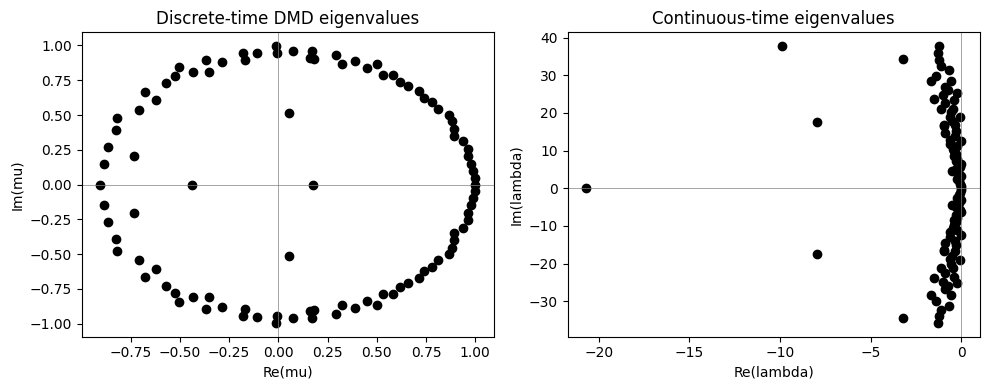

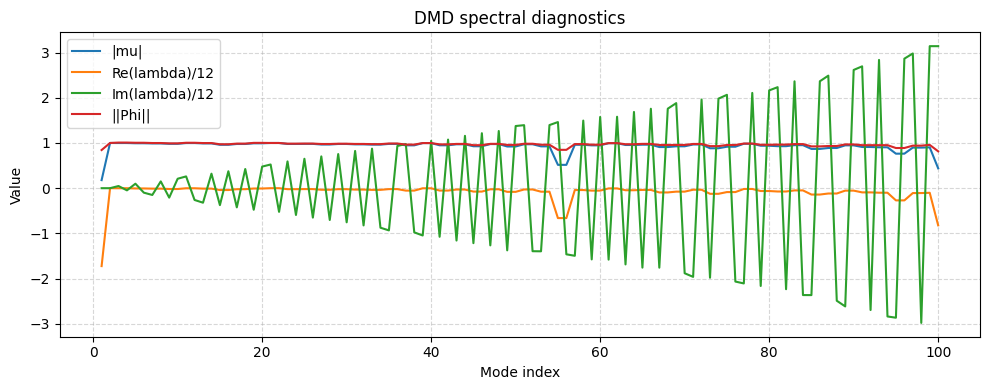

In [10]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(np.real(mu), np.imag(mu), color='black')
plt.xlabel('Re(mu)')
plt.ylabel('Im(mu)')
plt.title('Discrete-time DMD eigenvalues')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.subplot(1, 2, 2)
plt.scatter(np.real(lambda_cont), np.imag(lambda_cont), color='black')
plt.xlabel('Re(lambda)')
plt.ylabel('Im(lambda)')
plt.title('Continuous-time eigenvalues')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()

norm_phi = np.linalg.norm(Phi, axis=0)
plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, r + 1), np.abs(mu), label='|mu|')
plt.plot(np.arange(1, r + 1), np.real(lambda_cont) / 12.0, label='Re(lambda)/12')
plt.plot(np.arange(1, r + 1), np.imag(lambda_cont) / 12.0, label='Im(lambda)/12')
plt.plot(np.arange(1, r + 1), norm_phi, label='||Phi||')
plt.xlabel('Mode index')
plt.ylabel('Value')
plt.title('DMD spectral diagnostics')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

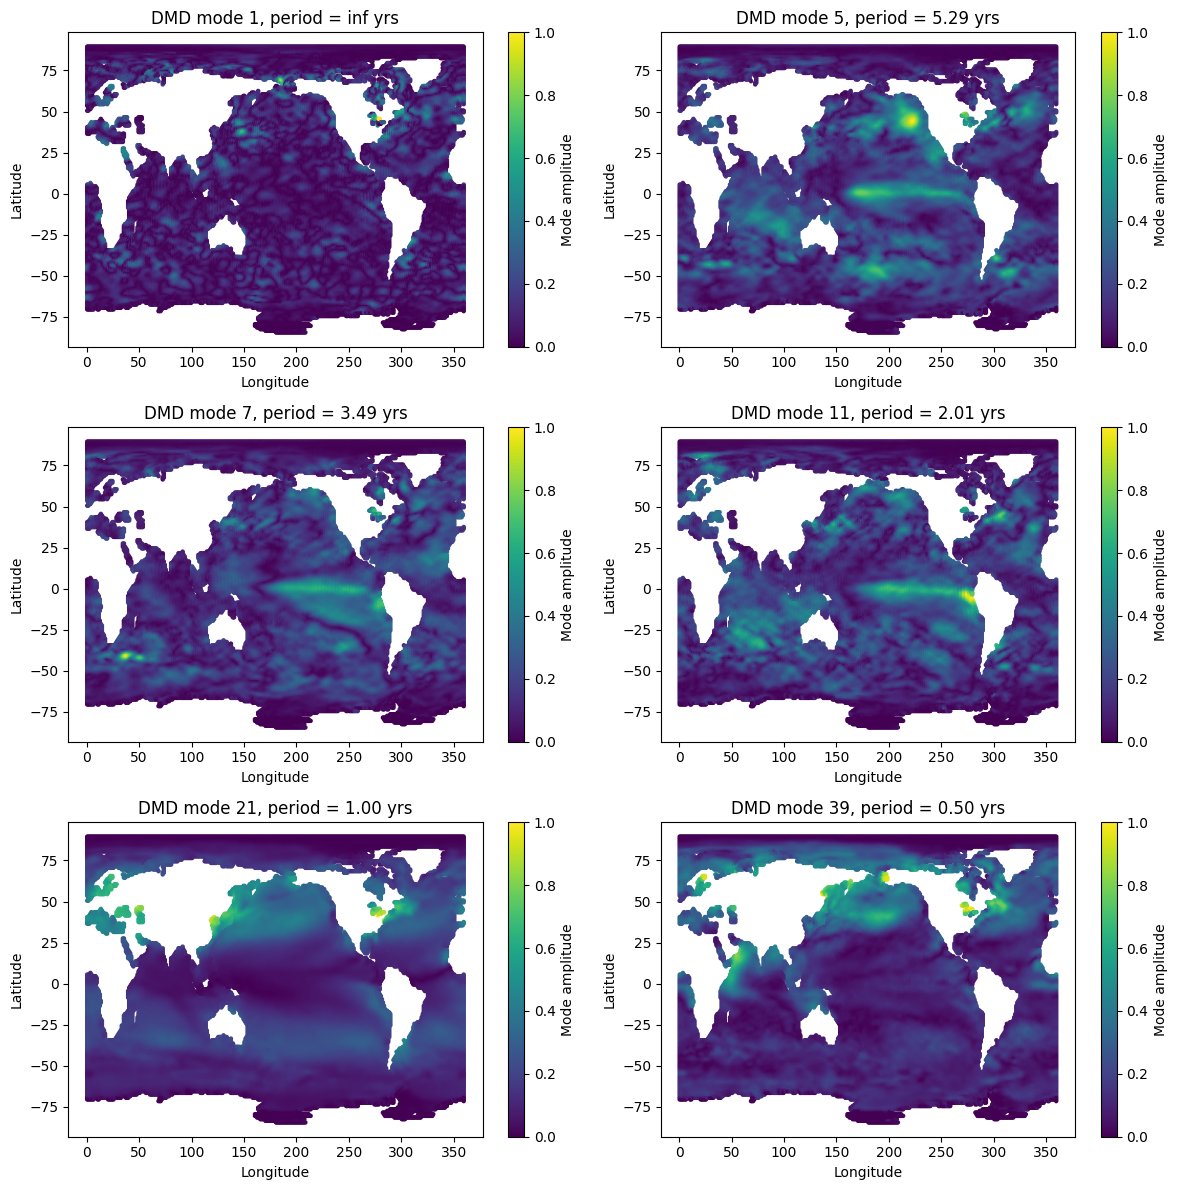

In [11]:
modes_to_plot = [1, 5, 7, 11, 21, 39]  # 1-based indices shown for readability
plt.figure(figsize=(12, 12))
for i, mode_index in enumerate(modes_to_plot, start=1):
    mode_idx = mode_index - 1
    period_years = np.inf if omega[mode_idx] == 0 else 2 * np.pi / np.abs(omega[mode_idx])
    plt.subplot(3, 2, i)
    plt.scatter(Xlon, Xlat, c=normalize_vector(np.abs(Phi[:, mode_idx])), s=5, cmap='viridis')
    plt.colorbar(label='Mode amplitude')
    plt.title(f'DMD mode {mode_index}, period = {period_years:.2f} yrs')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
plt.tight_layout()